# 03 - Object Detection (nach Solver-Logik)

## Übersicht
Dieses Notebook repliziert die exakte Logik der Objekterkennung aus dem `solver`-Verzeichnis.

1. **ImageLoader Pipeline** - Das Bild wird vorverarbeitet (Grayscale, Blur, Otsu's Threshold), um ein Binärbild zu erzeugen.
2. **ShapeDetector Pipeline** - Auf das Binärbild wird ein Sobel-Filter angewendet, um ein Kanten-Gradientenbild zu erhalten.
3. **PieceDetector Pipeline** - `findContours` wird auf dem Gradientenbild ausgeführt. Eine spezielle Heuristik trennt den Rahmen von den Puzzleteilen.

### Packages und Testbild laden

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import sys

In [7]:
image_path = '../data/image-007.png'
original_image = cv2.imread(image_path)

### 1. ImageLoader Pipeline
Der `ImageLoader` erzeugt aus dem Rohbild ein sauberes Binärbild.

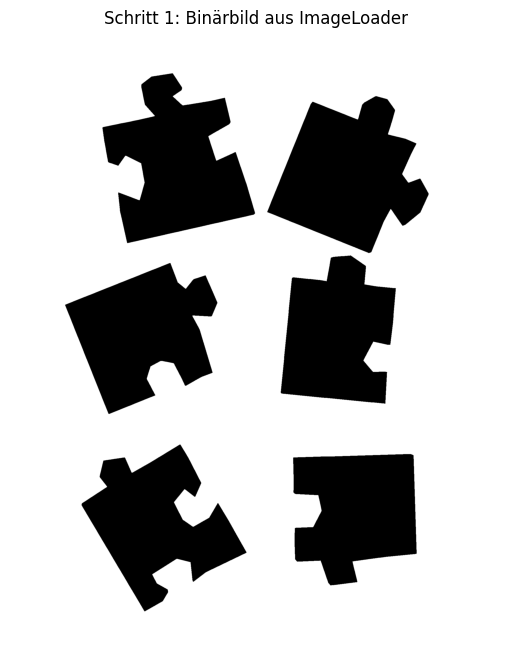

In [8]:
def image_loader_clean(img):
    grayscale = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(grayscale, (5, 5), 0)
    _, threshold = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return threshold

binary_image = image_loader_clean(original_image)

plt.figure(figsize=(8, 8))
plt.imshow(binary_image, cmap='gray')
plt.title('Schritt 1: Binärbild aus ImageLoader')
plt.axis('off')
plt.show()

### 2. ShapeDetector Pipeline
Der `ShapeDetector` nimmt das Binärbild und erzeugt daraus ein Gradientenbild. Dieses (und nicht das Binärbild) ist die Grundlage für die Konturfindung.

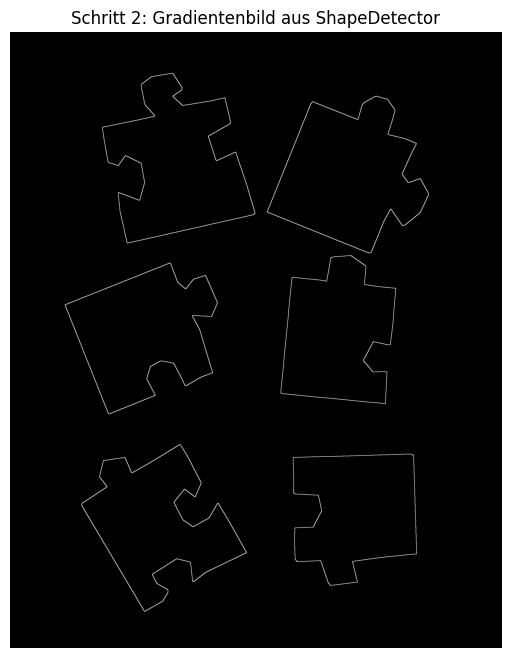

In [9]:
def shape_detector_detect(img):
    gradient_x = cv2.Sobel(img, cv2.CV_16S, 1, 0)
    gradient_y = cv2.Sobel(img, cv2.CV_16S, 0, 1)
    gradient_x_absolute = abs(gradient_x)
    gradient_y_absolute = abs(gradient_y)
    return np.minimum(gradient_x_absolute + gradient_y_absolute, 255).astype(np.uint8)

gradient_image_for_contours = shape_detector_detect(binary_image)

plt.figure(figsize=(8, 8))
plt.imshow(gradient_image_for_contours, cmap='gray')
plt.title('Schritt 2: Gradientenbild aus ShapeDetector')
plt.axis('off')
plt.show()

### 3. PieceDetector Pipeline (Erkennungsteil)
Der `PieceDetector` findet Konturen im Gradientenbild und nutzt eine Heuristik (x-Position < 30%) zur Identifizierung des Rahmens.

Anzahl gefundener Konturen: 6
Puzzlerahmen erkannt.
Anzahl Puzzleteile erkannt: 3


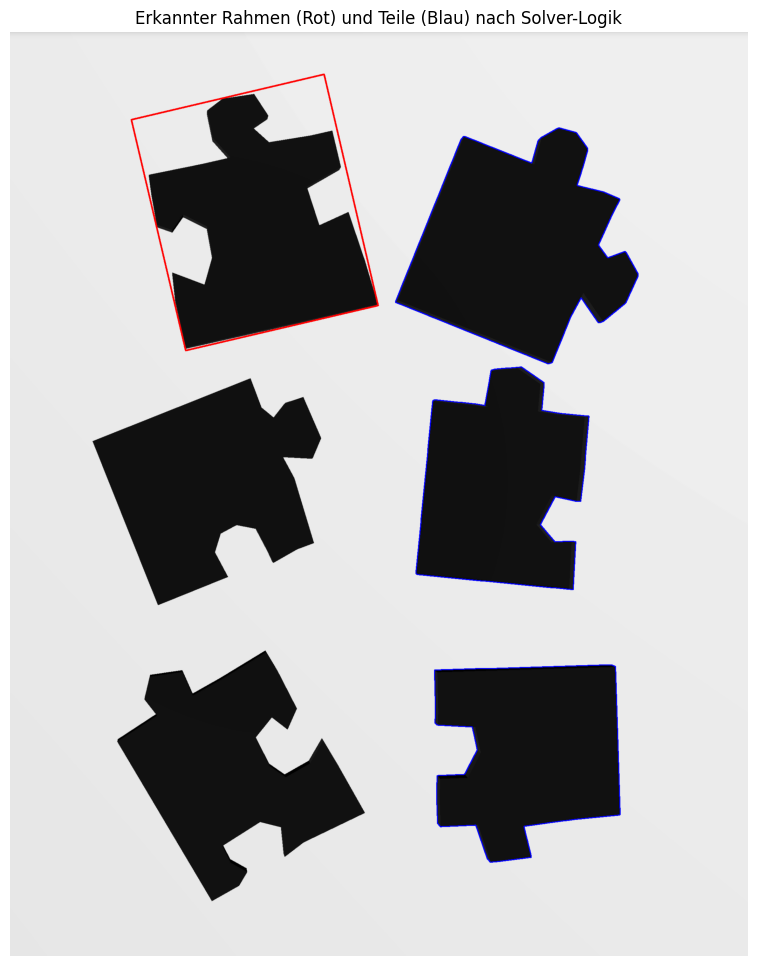

In [10]:
def normalize_coordinate(img, x, y):
    img_height, img_width = img.shape[:2]
    y = img_height - y
    longer_dimension = max(img_width, img_height)
    x_norm = x * 100 / longer_dimension
    y_norm = y * 100 / longer_dimension
    return (x_norm, y_norm)

FRAME_WIDTH_PERCENTAGE = 30

contours, _ = cv2.findContours(gradient_image_for_contours, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

frame_contour = None
piece_contours = []

for contour in contours:
    if cv2.contourArea(contour) < 100:
        continue
    is_frame = False
    for point in contour:
        x, y = point[0]
        norm_x, _ = normalize_coordinate(original_image, x, y)
        if norm_x < FRAME_WIDTH_PERCENTAGE:
            is_frame = True
            break
    if is_frame:
        frame_contour = contour
    else:
        piece_contours.append(contour)

print(f'Anzahl gefundener Konturen: {len(contours)}')
if frame_contour is not None:
    print('Puzzlerahmen erkannt.')
print(f'Anzahl Puzzleteile erkannt: {len(piece_contours)}')

image_final_detection = original_image.copy()

if frame_contour is not None:
    rect = cv2.minAreaRect(frame_contour)
    box = cv2.boxPoints(rect)
    box = np.intp(box)
    cv2.drawContours(image_final_detection, [box], 0, (0, 0, 255), 3)

if piece_contours:
    cv2.drawContours(image_final_detection, piece_contours, -1, (255, 0, 0), 2)

plt.figure(figsize=(12, 12))
plt.imshow(cv2.cvtColor(image_final_detection, cv2.COLOR_BGR2RGB))
plt.title('Erkannter Rahmen (Rot) und Teile (Blau) nach Solver-Logik')
plt.axis('off')
plt.show()

### Zusammenfassung
Dieses Notebook hat den exakten Objekterkennungs-Workflow des Solvers repliziert. Die wichtigsten Erkenntnisse sind:

1.  **Spezifische Pipeline**: Der Solver verwendet eine mehrstufige Kette (`Loader` -> `ShapeDetector` -> `PieceDetector`), bei der das Ergebnis eines Schritts die Eingabe für den nächsten ist. Insbesondere wird `findContours` auf einem **Gradientenbild** und nicht, wie üblich, auf einem reinen Binärbild ausgeführt.
2.  **Rahmen-Heuristik**: Der Rahmen wird nicht über seine Grösse, sondern über seine Position am linken Bildrand identifiziert. Dies ist eine wichtige, domänenspezifische Annahme.
3.  **Detaillierte Konturen**: Durch `CHAIN_APPROX_NONE` werden alle Konturpunkte beibehalten, was für die spätere, detaillierte Kantenanalyse im `PolygonUtility` notwendig ist.